# Slab and SiPM geometry check

This notebook plots the top view of the 50 x 50 cm slab and the 8 x 8 SiPM grid.

Assumptions used here:
- The slab is centered at the origin, so its in-plane edges are at `x = +/-25 cm` and `z = +/-25 cm`.
- The SiPMs are arranged on an 8 x 8 grid with `6.25 cm` pitch.
- The first and last SiPM centers are half a pitch from the slab edges, so the center coordinates are `-21.875, -15.625, ..., 21.875 cm`.

This matches the placement formulas in `geometry/main.gdml`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

%matplotlib inline

slab_size_cm = 50.0
pitch_cm = 6.25
n_sipm_per_side = 8

half_size_cm = slab_size_cm / 2
edge_offset_cm = pitch_cm / 2
axis_coords_cm = np.linspace(
    -half_size_cm + edge_offset_cm,
    half_size_cm - edge_offset_cm,
    n_sipm_per_side,
)

axis_coords_cm


array([-21.875, -15.625,  -9.375,  -3.125,   3.125,   9.375,  15.625,
        21.875])

In [5]:
x_grid, z_grid = np.meshgrid(axis_coords_cm, axis_coords_cm)

muon_hit_cm = (10.0, 0.0)

sipm_positions = pd.DataFrame(
    {
        "sipm_id": np.arange(1, x_grid.size + 1),
        "x_cm": x_grid.ravel(),
        "z_cm": z_grid.ravel(),
    }
)

sipm_positions.head(12)


,sipm_id,x_cm,z_cm
0,1,-21.875,-21.875
1,2,-15.625,-21.875
2,3,-9.375,-21.875
3,4,-3.125,-21.875
4,5,3.125,-21.875
5,6,9.375,-21.875
6,7,15.625,-21.875
7,8,21.875,-21.875
8,9,-21.875,-15.625
9,10,-15.625,-15.625


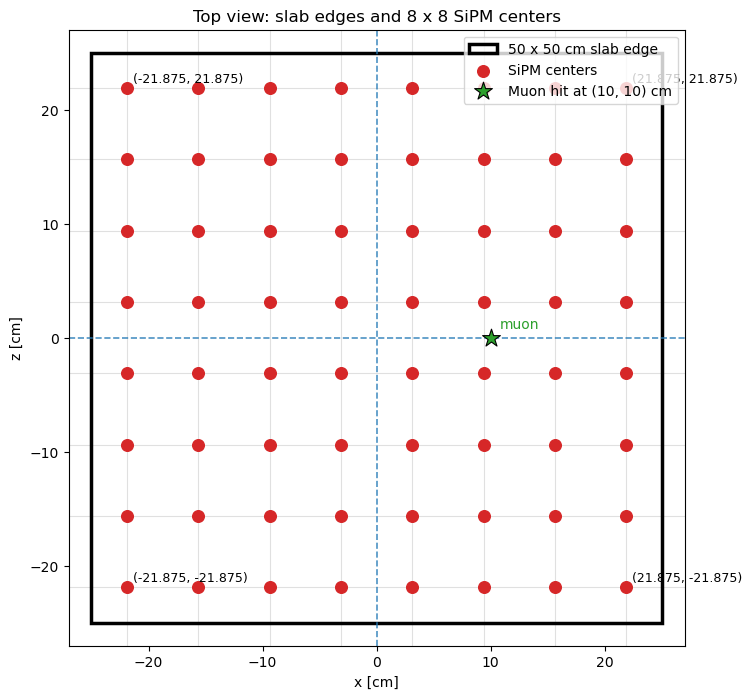

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

slab = Rectangle(
    (-half_size_cm, -half_size_cm),
    slab_size_cm,
    slab_size_cm,
    fill=False,
    linewidth=2.5,
    edgecolor="black",
    label="50 x 50 cm slab edge",
)
ax.add_patch(slab)

ax.scatter(
    sipm_positions["x_cm"],
    sipm_positions["z_cm"],
    s=70,
    color="tab:red",
    label="SiPM centers",
    zorder=3,
)

ax.scatter(
    muon_hit_cm[0],
    muon_hit_cm[1],
    s=180,
    color="tab:green",
    marker="*",
    edgecolor="black",
    linewidth=0.8,
    label="Muon hit at (10, 10) cm",
    zorder=4,
)
ax.text(muon_hit_cm[0] + 0.8, muon_hit_cm[1] + 0.8, "muon", fontsize=10, color="tab:green")

for x in axis_coords_cm:
    ax.axvline(x, color="0.88", linewidth=0.8, zorder=0)
for z in axis_coords_cm:
    ax.axhline(z, color="0.88", linewidth=0.8, zorder=0)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1.2, alpha=0.8)
ax.axhline(0, color="tab:blue", linestyle="--", linewidth=1.2, alpha=0.8)

corner_labels = [
    (-21.875, -21.875),
    (21.875, -21.875),
    (-21.875, 21.875),
    (21.875, 21.875),
]
for x, z in corner_labels:
    ax.text(x + 0.5, z + 0.5, f"({x:.3f}, {z:.3f})", fontsize=9)

ax.set_title("Top view: slab edges and 8 x 8 SiPM centers")
ax.set_xlabel("x [cm]")
ax.set_ylabel("z [cm]")
ax.set_aspect("equal")
ax.set_xlim(-27, 27)
ax.set_ylim(-27, 27)
ax.legend(loc="upper right")
ax.grid(False)
plt.show()


In [4]:
print(f"Slab edges: x, z in [{-half_size_cm:.1f}, {half_size_cm:.1f}] cm")
print(f"SiPM pitch: {pitch_cm:.2f} cm")
print(f"Distance from slab edge to first SiPM center: {edge_offset_cm:.3f} cm")
print(f"Number of SiPMs: {len(sipm_positions)}")
print(f"Muon hit: x = {muon_hit_cm[0]:.1f} cm, z = {muon_hit_cm[1]:.1f} cm")

sipm_positions


Slab edges: x, z in [-25.0, 25.0] cm
SiPM pitch: 6.25 cm
Distance from slab edge to first SiPM center: 3.125 cm
Number of SiPMs: 64
Muon hit: x = 10.0 cm, z = 10.0 cm


,sipm_id,x_cm,z_cm
0,1,-21.875,-21.875
1,2,-15.625,-21.875
2,3,-9.375,-21.875
3,4,-3.125,-21.875
4,5,3.125,-21.875
...,...,...,...
59,60,-3.125,21.875
60,61,3.125,21.875
61,62,9.375,21.875
62,63,15.625,21.875
